# Procesos de Media Móvil (MA)

## Introducción

En este cuaderno, exploraremos los procesos de media móvil (MA), su formulación matemática, y cómo implementarlos en Python.

## ¿Qué es un Proceso de Media Móvil (MA)?
Un proceso de media móvil de orden q, denotado como MA(q), modela el valor actual de una serie temporal como una combinación lineal de términos de ruido blanco pasados.La formulación matemática es:

$y[t] = μ + ε[t] + θ_1 ε[t-1] + θ_2 ε[t-2] + ... + θ_q ε[t-q]$

- μ es la media de la serie.
- θi son los coeficientes del modelo.
- ε[t] es ruido blanco.

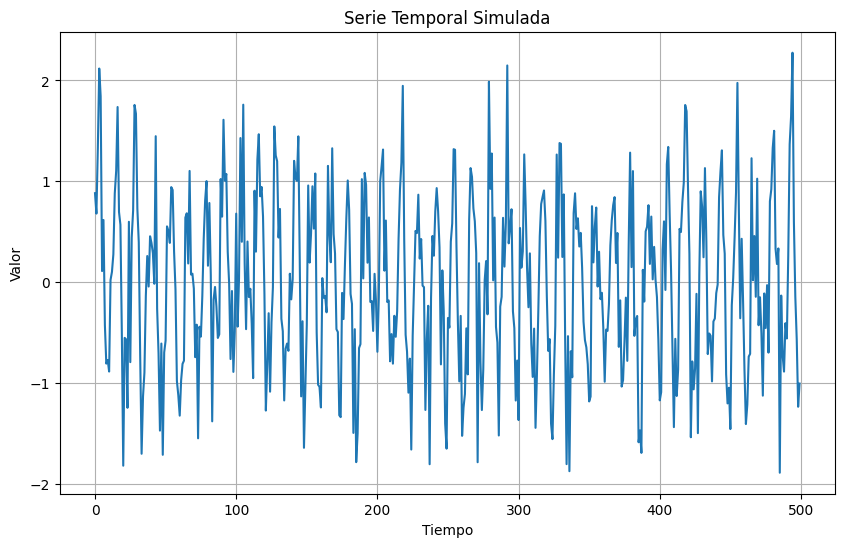

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Generar una serie temporal simulada
np.random.seed(0)
time = np.arange(0, 500, 1)
# series = np.sin(time * 0.1) + np.random.normal(0, 0.1, len(time))
series = np.sin(time * 0.5) + np.random.normal(0, 0.5, len(time))

# Visualizar la serie
df = pd.DataFrame({'Value': series})
plt.figure(figsize=(10, 6))
plt.plot(df['Value'])
plt.title('Serie Temporal Simulada')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

In [6]:
# Ajustar un modelo MA(1)
model = ARIMA(df['Value'], order=(0, 0, 1)) # order(p,d,q) significa (componente autorregresivo, componente de diferenciación, componente de media móvil)
model_fit = model.fit()

# Resumen del modelo
print(model_fit.summary())

# Predecir valores
predictions = model_fit.predict(start=len(df), end=len(df))
print(f'Predicción para el siguiente paso: {predictions.iloc[-1]}')

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  500
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -562.733
Date:                Thu, 12 Feb 2026   AIC                           1131.466
Time:                        20:49:07   BIC                           1144.110
Sample:                             0   HQIC                          1136.428
                                - 500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0086      0.048     -0.180      0.857      -0.102       0.085
ma.L1          0.4285      0.045      9.597      0.000       0.341       0.516
sigma2         0.5558      0.038     14.579      0.0

## ¿Qué simboliza sigma2?

En el contexto de los modelos de series temporales, sigma2 (o $\sigma^2$) representa la varianza del término de error (ruido blanco, $ε_t$).

### Interpretación:

Es una medida de la variabilidad de los errores del modelo.
- Un valor alto de $\sigma^2$ indica que los errores tienen una gran variabilidad, lo que sugiere que el modelo no captura bien la estructura de los datos.
- Un valor bajo de $\sigma^2$ indica que los errores tienen poca variabilidad, lo que sugiere que el modelo ajusta bien los datos.


## Pruebas de diagnóstico

Se utilizan para validar si el modelo ajustado es adecuado y si los residuos se comportan como ruido blanco. 

### Prueba de Ljung-Box
Evalúa si los residuos de un modelo de series temporales están correlacionados. 
- Prob(Q) < 0.05: los residuos están autocorrelacionados y el modelo no captura toda la estructura de los datos.
- Prob(Q) > 0.05: los residuos no muestran autocorrelación significativa y se comportan como ruido blanco por lo que el modelo captura la estructura de datos.

### Prueba de Jarque-Bera

Evalúa si los residuos siguen una distribución normal. 

- Prob(JB) < 0.05: los residuos no siguen una distribución normal.
- Prob(JB) > 0.05: los residuos siguen una distribución normal.


### Prueba de Heteroscedasticidad

Evalúa si la varianza de los residuos es constante a lo largo del tiempo.

- Prob(H) < 0.05: los residuos tienen varianza no constante.
- Prob(H) > 0.05: los residuos tienen varianza constante


### Skew

Mide la asimetría de la distribución de los residuos.

- Un valor de 0 indica una distribución simétrica.
- Un valor positivo indica una cola más larga a la derecha.
- Un valor negativo indica una cola más larga a la izquierda.


### Kurtosis

Mide el apuntamiento de la distribución de los residuos.

- Un valor de 3 indica una distribución normal (mesocúrtica).
- Un valor mayor que 3 indica una distribución más apuntada (leptocúrtica).
- Un valor menor que 3 indica una distribución menos apuntada (platicúrtica).



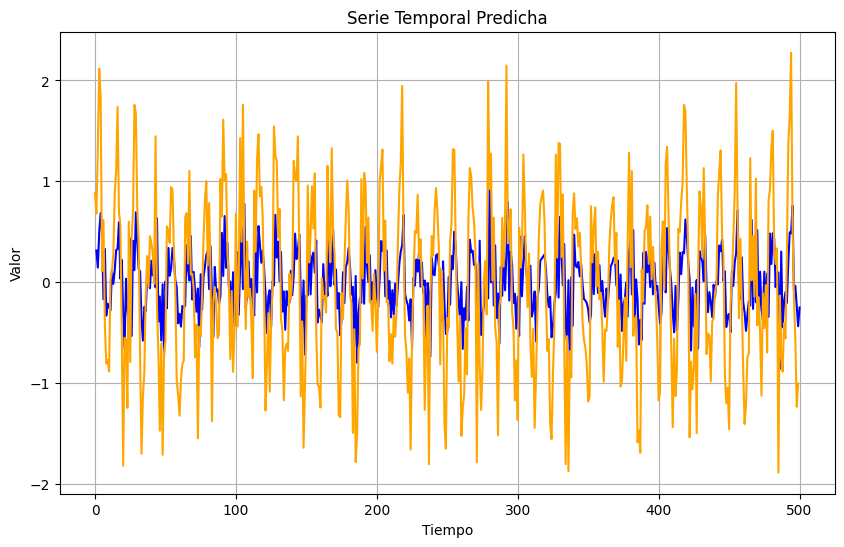

In [7]:
# Predecir valores para toda la serie
predictions = model_fit.predict(start=1, end=len(df))

plt.figure(figsize=(10, 6))
plt.plot(predictions, color="blue" )
plt.plot(df['Value'], color = "orange")
plt.title('Serie Temporal Predicha')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

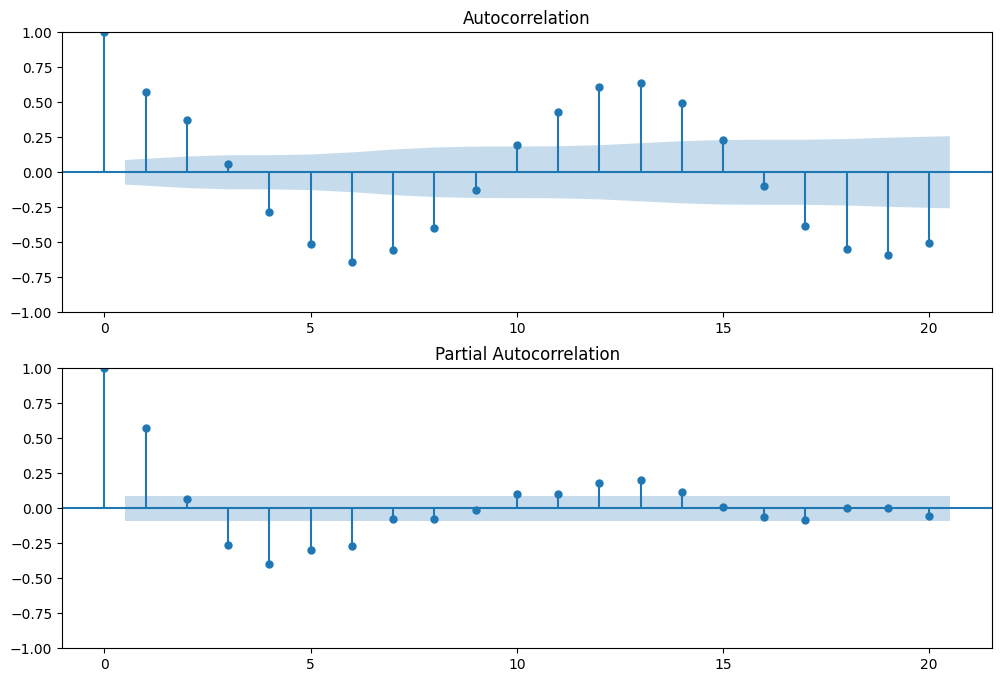

In [8]:
# Visualizar la función de autocorrelación (ACF) y autocorrelación parcial (PACF)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['Value'], lags=20, ax=ax1)
plot_pacf(df['Value'], lags=20, ax=ax2)
plt.show()

### Explicación de ACF y PACF
- **ACF (Autocorrelation Function)**: Mide la correlación entre la serie y sus valores rezagados. Es útil para identificar patrones en los datos.
- **PACF (Partial Autocorrelation Function)**: Mide la correlación entre la serie y sus valores rezagados, eliminando el efecto de los rezagos intermedios. Es útil para identificar el orden p en modelos AR.

### Interpretación de los Gráficos de ACF y PACF
#### ACF

- Si la ACF muestra picos significativos en rezagos específicos, puede indicar estacionalidad.
- Si la ACF decae lentamente, sugiere que la serie tiene una componente autorregresiva (AR).
- Si la ACF corta abruptamente después de un rezago q, sugiere un modelo MA(q).
#### PACF

- Si la PACF corta abruptamente después de un rezago p, sugiere un modelo AR(p).
- Si la PACF decae lentamente, sugiere que la serie tiene una componente de media móvil (MA).
